# 02 — Wax Pushes a Coin

First metal. The Steelpush model (`sim/steelpush.py`) is deliberately tiny:

- A push is a **force pair** along the line between the pusher's and the metal's
  centers — Newton's third law, equal and opposite, no exceptions.
- Strength falls off **linearly** with distance, reaching zero at max range
  (16 m default). Canon says pushes weaken with distance; the linear shape is a
  modeling choice, not lore.
- Nothing about anchoring is coded anywhere. "A grounded coin launches you,
  a midair coin doesn't" must **emerge** from the force pair plus the ground
  constraint, or the model is wrong.

Three experiments:

- **A.** Coin on the ground, Wax above it, constant push → he should launch and
  then hover-oscillate around a height we can predict on paper.
- **B.** Coin in open air, far from any ground → pushing it should give Wax
  almost nothing.
- **C.** The iconic move: drop a coin near the ground and ride it. Nobody tells
  the coin to become an anchor.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from sim import Body, World, Steelpush, GRAVITY_M_PER_S2, plot_heights, animate

WAX_MASS_KG = 80
COIN_MASS_KG = 0.004
PUSH_STRENGTH_N = 2000
PUSH_RANGE_M = 16

## Experiment A — anchored launch and the hover ceiling

Paper prediction first. With the coin pinned to the ground, Wax rises until the
weakening push balances his weight. The push at separation $d$ is
$F(d) = S\,(1 - d/R)$, so equilibrium sits at

$$d_{eq} = R\left(1 - \frac{m g}{S}\right)$$

With $S = 2000$ N, $R = 16$ m, $m = 80$ kg: $d_{eq} \approx 9.72$ m. There is no
air drag in the engine, so he shouldn't *settle* there — he should overshoot and
oscillate around it forever, like a mass on a spring.

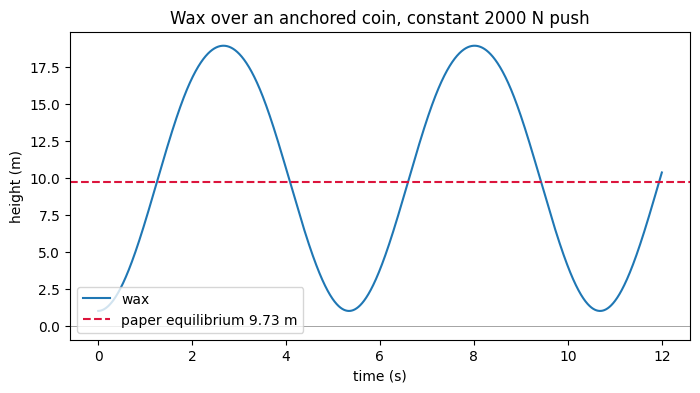

late-run mean height: 9.93 m  (paper says 9.73 m)


In [2]:
world = World()
coin = world.add_body(Body("coin", COIN_MASS_KG, (0, 0.01), radius_m=0.01, is_metal=True))
wax = world.add_body(Body("wax", WAX_MASS_KG, (0, 1.0)))
push = world.add_power(Steelpush(wax, coin, PUSH_STRENGTH_N, PUSH_RANGE_M))
push.active = True
world.run(12.0)

equilibrium_height = PUSH_RANGE_M * (1 - WAX_MASS_KG * GRAVITY_M_PER_S2 / PUSH_STRENGTH_N) + coin.position[1]

ax = plot_heights(world.history, ["wax"])
ax.axhline(equilibrium_height, color="crimson", linestyle="--",
           label=f"paper equilibrium {equilibrium_height:.2f} m")
ax.set_title("Wax over an anchored coin, constant 2000 N push")
ax.legend()
plt.show()

wax_data = world.history.body("wax")
late_mean = wax_data["y"][len(wax_data["y"]) // 2:].mean()
print(f"late-run mean height: {late_mean:.2f} m  (paper says {equilibrium_height:.2f} m)")

The oscillation is undamped because nothing in the world eats energy yet — no
air drag, no burn-rate modulation. A real Coinshot would feather the push to
settle; our Wax holds the metaphorical pedal to the floor. The *mean* matching
the paper equilibrium is the pass/fail criterion, and the lesson is bigger than
it looks: **steady hovering on a constant push is unstable-comfortable at best.**
Hover control will eventually be its own experiment.

## Experiment B — a midair coin is (almost) no anchor

Same push, but at 50 m altitude so the coin can't reach the ground while in
range. The coin weighs 4 g against Wax's 80 kg — it should rocket out of the
16 m range in milliseconds, and the impulse Wax collects in that window should
be tiny.

(First run of this experiment was accidentally staged near the ground — the
pushed coin slammed down, *became* an anchor, and launched Wax. Wrong test,
right physics: that accident is Experiment C.)

In [3]:
world = World()
coin = world.add_body(Body("coin", COIN_MASS_KG, (0, 49.5), radius_m=0.01, is_metal=True))
wax = world.add_body(Body("wax", WAX_MASS_KG, (0, 50.0)))
push = world.add_power(Steelpush(wax, coin, PUSH_STRENGTH_N, PUSH_RANGE_M))
push.active = True
world.run(1.0)

wax_data = world.history.body("wax")
# Subtract free-fall to isolate what the push contributed.
upward_kick = (wax_data["vy"] + GRAVITY_M_PER_S2 * wax_data["t"]).max()
print(f"Wax's total upward kick from the push: {upward_kick:.2f} m/s")
print(f"(for scale, the anchored launch in Experiment A peaked near 14 m/s)")

Wax's total upward kick from the push: 0.15 m/s
(for scale, the anchored launch in Experiment A peaked near 14 m/s)


## Experiment C — drop a coin and ride it

Wax at 3 m, coin just below him, push on. Watch the sequence: the coin is
hammered into the ground in a few milliseconds, and the instant it grounds,
the same force pair that did almost nothing in open air launches 80 kg of
lawman skyward. **No line of code knows what an anchor is.**

coin grounded at t = 4 ms; Wax peaks at 16.5 m


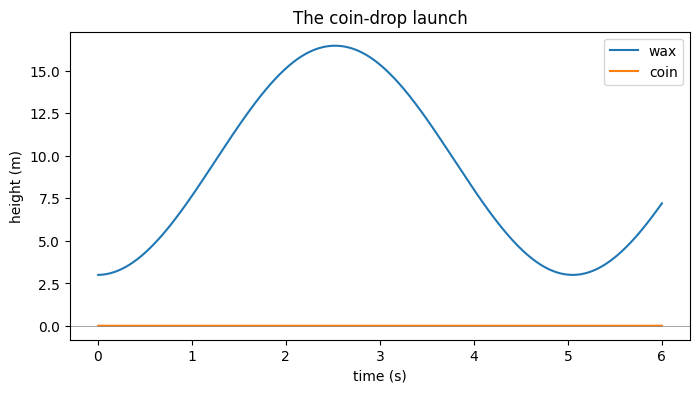

In [4]:
world = World()
coin = world.add_body(Body("coin", COIN_MASS_KG, (0, 2.5), radius_m=0.01, is_metal=True))
wax = world.add_body(Body("wax", WAX_MASS_KG, (0, 3.0)))
push = world.add_power(Steelpush(wax, coin, PUSH_STRENGTH_N, PUSH_RANGE_M))
push.active = True
world.run(6.0)

coin_data = world.history.body("coin")
wax_data = world.history.body("wax")
coin_grounded_at = coin_data["t"][np.argmax(coin_data["on_ground"])]
print(f"coin grounded at t = {coin_grounded_at*1000:.0f} ms; Wax peaks at {wax_data['y'].max():.1f} m")

ax = plot_heights(world.history, ["wax", "coin"])
ax.set_title("The coin-drop launch")
plt.show()

In [5]:
HTML(animate(world.history, x_limits=(-4, 4)).to_jshtml())

## Findings

1. **Anchoring is emergent.** Grounded coin → full launch; open-air coin →
   ~0.15 m/s of nothing. The engine has no concept of "anchor"; the ground
   constraint plus Newton's third law produce the whole Coinshot playbook.
2. **The hover ceiling is predictable on paper** and the sim oscillates around
   it, undamped, exactly as a drag-free world should.
3. **Next (03):** give Wax his ironmind — store weight to fly higher on the
   same coin, tap weight at apex to land like artillery. Mass changes conserve
   momentum (canon), which should make mid-flight weight shifts feel genuinely
   weird in the plots. Looking forward to it.